In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv('churn_Modelling.csv')
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df = pd.get_dummies(df, columns =['Geography'], drop_first=True)
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,1,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,0,False,True


In [5]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

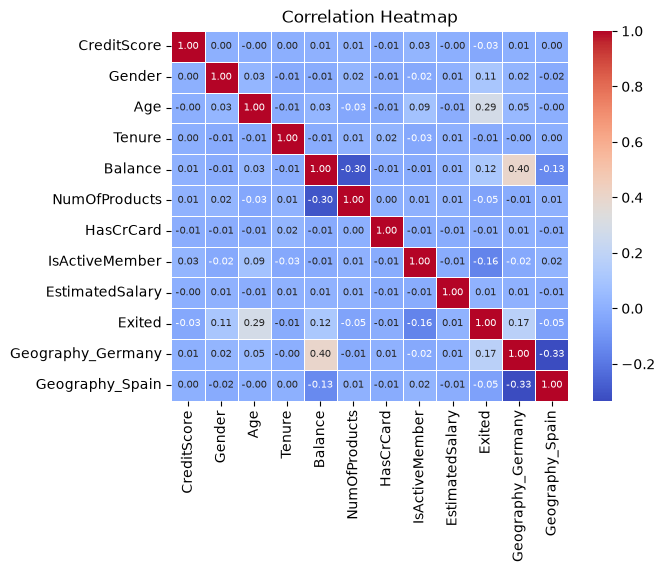

In [6]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', 
            fmt='.2f', annot_kws={'size': 7},
            linewidths=0.5, linecolor='white')
plt.title('Correlation Heatmap')
plt.show()

In [7]:
x = df.drop('Exited', axis=1).values
y = df['Exited'].values

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rfc.fit(x_train, y_train)
rfc_pred = rfc.predict(x_test)

Axes(0.125,0.11;0.62x0.77)


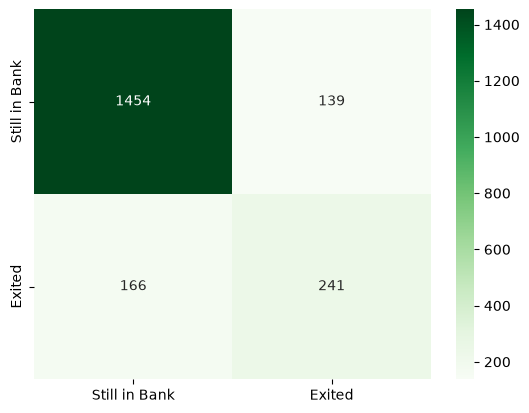

In [10]:
cm = confusion_matrix(y_test, rfc_pred)
print(sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Still in Bank', 'Exited'], yticklabels=['Still in Bank', 'Exited']))


In [11]:
print(classification_report(y_test, rfc_pred, target_names=['Still in Bank', 'Exited']))
print("Accuracy:", rfc.score(x_test, y_test))

               precision    recall  f1-score   support

Still in Bank       0.90      0.91      0.91      1593
       Exited       0.63      0.59      0.61       407

     accuracy                           0.85      2000
    macro avg       0.77      0.75      0.76      2000
 weighted avg       0.84      0.85      0.85      2000

Accuracy: 0.8475


In [12]:
x_test_pred = rfc.predict(x_test)
print("Predictions on test set:", x_test_pred)
print("Actual values on test set:", y_test)

Predictions on test set: [0 0 0 ... 1 0 0]
Actual values on test set: [0 0 0 ... 1 0 0]


In [ ]:
new_pred = rfc.predict(np.array([[0.2,18,2.3,10,3,43,65,78,0.4,6.6,0.77777]]))
print('Prediction probability:', rfc.predict_proba(np.array([[4.80,18,2.3,10,3,43,65,78,0.4,6.6,0.77777]])))
print("New Prediction (0=Still in Bank, 1=Exited):", new_pred[0])

Prediction probability: [[0.49 0.51]]
New Prediction (0=Still in Bank, 1=Exited): 1
